# Processamento de Imagens — Histogramas e Transformações de Intensidade

**Autor:** Gabriel Santos

Três fotos próprias (uma subexposta, uma superexposta e uma bem exposta) são convertidas para tons de cinza, têm seus histogramas analisados e recebem, cada uma, uma única operação de transformação de intensidade (expansão de contraste, equalização de histograma ou correção de gamma), escolhida a partir do formato do histograma original. Ao final, as três são comparadas quanto ao impacto da operação aplicada.


## 1. Setup e funções reaproveitadas


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

plt.rcParams['figure.figsize'] = (6, 3)


Funções reaproveitadas do notebook da aula (histograma, expansão de contraste, equalização e correção de gamma), implementadas com NumPy e com as funções prontas do OpenCV.


In [2]:
def histograma(img_gray, titulo="Histograma", ax=None):
    """Calcula e plota o histograma de uma imagem em tons de cinza (0-255)."""
    hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256]).flatten()
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 3))
    ax.bar(np.arange(256), hist, width=1.0, color="steelblue")
    ax.set_title(titulo)
    ax.set_xlabel("Intensidade (0-255)")
    ax.set_ylabel("Nº de pixels")
    ax.set_xlim([0, 255])
    return hist, ax


def expandir_contraste(img_gray, L=None, H=None):
    """Expansão de contraste (contrast stretching) linear para a faixa [0, 255].
    L = intensidade mínima considerada, H = intensidade máxima considerada.
    Se L/H não forem informados, usa o mínimo/máximo reais da imagem."""
    if L is None:
        L = int(img_gray.min())
    if H is None:
        H = int(img_gray.max())
    if H <= L:
        return img_gray.copy(), L, H
    img_f = img_gray.astype(np.float32)
    out = (img_f - L) * (255.0 / (H - L))
    out = np.clip(out, 0, 255).astype(np.uint8)
    return out, L, H


def equalizar(img_gray):
    """Equalização de histograma usando a função pronta do OpenCV."""
    return cv2.equalizeHist(img_gray)


def corrigir_gamma(img_gray, gamma=1.0):
    """Correção de gamma (transformação de potência) via LUT: s = (r/255)^gamma * 255.
    gamma < 1 clareia a imagem (expande a faixa de tons escuros e comprime a de tons claros).
    gamma > 1 escurece a imagem (comprime a faixa de tons escuros e expande a de tons claros)."""
    tabela = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)]).astype(np.uint8)
    return cv2.LUT(img_gray, tabela)


In [3]:
def figura_antes_depois(gray, out, titulo_antes, titulo_depois, sup_titulo):
    """Monta a figura 2x2: imagem antes/depois (linha 1) e histogramas antes/depois (linha 2)."""
    fig, axs = plt.subplots(2, 2, figsize=(10, 7))
    fig.suptitle(sup_titulo, fontsize=13)

    axs[0, 0].imshow(gray, cmap="gray", vmin=0, vmax=255)
    axs[0, 0].set_title(titulo_antes)
    axs[0, 0].axis("off")

    axs[0, 1].imshow(out, cmap="gray", vmin=0, vmax=255)
    axs[0, 1].set_title(titulo_depois)
    axs[0, 1].axis("off")

    histograma(gray, f"Histograma - {titulo_antes}", ax=axs[1, 0])
    histograma(out, f"Histograma - {titulo_depois}", ax=axs[1, 1])

    plt.tight_layout()
    plt.show()
    return fig


In [4]:
def carregar_upload(prompt):
    """Abre o widget de upload do Colab e retorna a imagem carregada em BGR (formato OpenCV).
    Fora do Colab, pede o caminho do arquivo local."""
    print(prompt)
    if IN_COLAB:
        uploaded = files.upload()
        nome_arquivo = list(uploaded.keys())[0]
        dados = np.frombuffer(uploaded[nome_arquivo], np.uint8)
        img_bgr = cv2.imdecode(dados, cv2.IMREAD_COLOR)
    else:
        caminho = input("Caminho do arquivo local: ").strip()
        nome_arquivo = caminho
        img_bgr = cv2.imread(caminho, cv2.IMREAD_COLOR)
    assert img_bgr is not None, "Não foi possível carregar a imagem. Tente novamente."
    print(f"Carregado: {nome_arquivo}  |  shape: {img_bgr.shape}")
    return img_bgr, nome_arquivo


Função auxiliar que resume numericamente o histograma (média, desvio padrão e fração de pixels em sombras, meios-tons e realces), usada para sustentar a leitura visual dos gráficos.


In [5]:
def resumo_histograma(img_gray):
    media = img_gray.mean()
    desvio = img_gray.std()
    total = img_gray.size
    sombras = np.sum(img_gray <= 63) / total * 100
    meios = np.sum((img_gray > 63) & (img_gray <= 191)) / total * 100
    realces = np.sum(img_gray > 191) / total * 100
    print(f"Média: {media:.1f}  |  Desvio padrão: {desvio:.1f}")
    print(f"Sombras (0-63): {sombras:.1f}%  |  Meios-tons (64-191): {meios:.1f}%  |  Realces (192-255): {realces:.1f}%")


## 2. Imagem 1 — Foto escura demais

Retrato feito em ambiente interno mal iluminado, apenas com a luz que recorta o contorno do rosto e do ombro.


Envie a foto ESCURA DEMAIS:


Saving foto-escura.jpeg to foto-escura.jpeg
Carregado: foto-escura.jpeg  |  shape: (243, 148, 3)


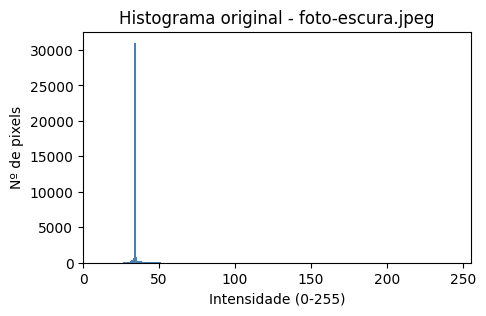

Média: 35.5  |  Desvio padrão: 10.9
Sombras (0-63): 98.4%  |  Meios-tons (64-191): 1.5%  |  Realces (192-255): 0.1%


In [6]:
img1_bgr, nome1 = carregar_upload("Envie a foto ESCURA DEMAIS:")
gray1 = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2GRAY)

histograma(gray1, f"Histograma original - {nome1}")
plt.show()
resumo_histograma(gray1)


### Diagnóstico

O histograma é um pico único, estreito e muito alto, centrado em torno de 30: a média é 35.5 com desvio padrão de apenas 10.9, e 98.4% dos pixels caem na faixa de sombras (0–63), contra 1.5% de meios-tons e 0.1% de realces. A imagem inteira ocupa menos de um quarto da faixa dinâmica, e toda a informação da cena — o contorno do rosto, o ombro, o fundo — está separada por pouquíssimos níveis de cinza. Trata-se de uma imagem severamente subexposta: o conteúdo chegou a ser registrado, mas com um contraste tão baixo que se torna imperceptível.

### Operação escolhida: correção de gamma, γ = 0.4

A massa do histograma está na base da faixa, e é exatamente ali que a curva de potência com γ < 1 tem maior inclinação: ela estica os tons escuros sobre um intervalo de saída muito mais largo e comprime a região clara, que nesta imagem está praticamente vazia e portanto não tem o que perder. Com γ = 0.4 os pixels do pico principal (≈ 30) são remapeados para ≈ 108, abrindo o contraste dentro da própria sombra.

As outras duas opções seriam piores aqui. A expansão de contraste é linear e depende dos extremos: os 0.1% de pixels acima de 191 — o brilho na orelha e no ombro — já bastam para levar H para perto do topo da faixa, e com isso o fator de esticamento fica pequeno demais para abrir o pico principal. A equalização, num histograma tão concentrado, distribuiria um punhado de níveis de cinza por toda a faixa e amplificaria fortemente o ruído do sensor, que é justamente o que domina uma foto subexposta como esta.

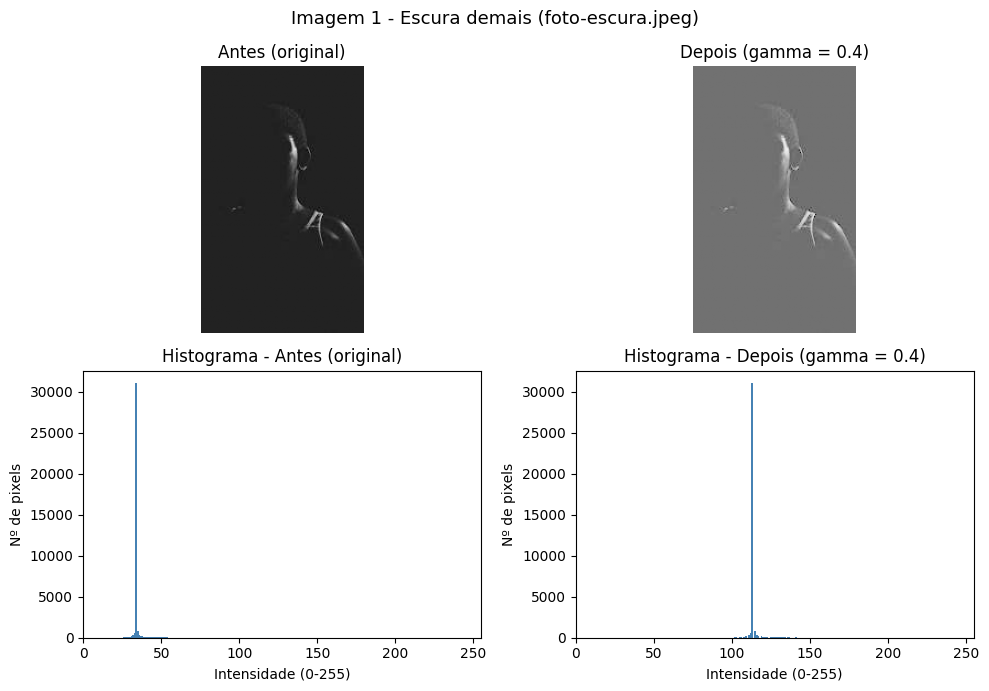

In [7]:
gamma1 = 0.4
out1 = corrigir_gamma(gray1, gamma=gamma1)

fig1 = figura_antes_depois(
    gray1, out1,
    "Antes (original)", f"Depois (gamma = {gamma1})",
    f"Imagem 1 - Escura demais ({nome1})"
)


## 3. Imagem 2 — Foto clara/saturada demais

Vegetação em contraluz numa praia com névoa, fotografada contra o sol.


Envie a foto CLARA/SATURADA DEMAIS:


Saving foto-clara.jpeg to foto-clara.jpeg
Carregado: foto-clara.jpeg  |  shape: (415, 740, 3)


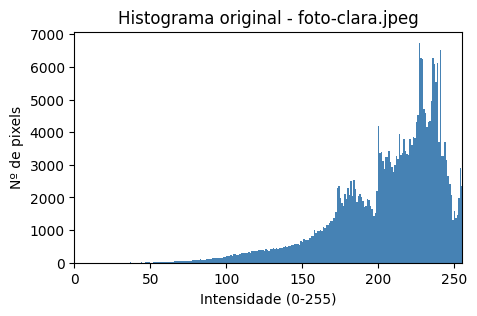

Média: 207.0  |  Desvio padrão: 35.2
Sombras (0-63): 0.1%  |  Meios-tons (64-191): 27.7%  |  Realces (192-255): 72.2%


In [8]:
img2_bgr, nome2 = carregar_upload("Envie a foto CLARA/SATURADA DEMAIS:")
gray2 = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2GRAY)

histograma(gray2, f"Histograma original - {nome2}")
plt.show()
resumo_histograma(gray2)


### Diagnóstico

O histograma está empurrado contra a extremidade direita: a média é 207.0 e 72.2% dos pixels estão na faixa de realces (192–255), contra 27.7% de meios-tons e apenas 0.1% de sombras. A massa começa a subir por volta de 150 e se concentra entre 200 e 255, com pico em torno de 230. É uma imagem superexposta: o céu e a névoa ocupam o topo da faixa e os detalhes da vegetação ficam espremidos contra o limite superior, de modo que as diferenças que deveriam separar as folhas do fundo se reduzem aos poucos níveis que ainda restam antes de 255.

### Operação escolhida: correção de gamma, γ = 2.2

Com γ > 1 a curva de potência comprime a região clara e devolve os realces para o meio da faixa, que aqui está desocupado — é a operação que ataca diretamente o problema desta imagem. Com γ = 2.2, um pixel em 200 cai para 149 e um em 230 cai para 203, recuperando separação entre a vegetação e o fundo claro.

A expansão de contraste teria pouco efeito, porque o histograma já ocupa os dois extremos: ainda há 0.1% de pixels abaixo de 63 e a massa encosta em 255, então L e H ficam próximos dos limites da faixa, o fator de esticamento fica perto de 1 e a transformação vira quase a identidade. A equalização, por sua vez, achataria à força uma cena naturalmente suave e de pouca textura, exagerando variações mínimas da névoa e produzindo um resultado artificial.

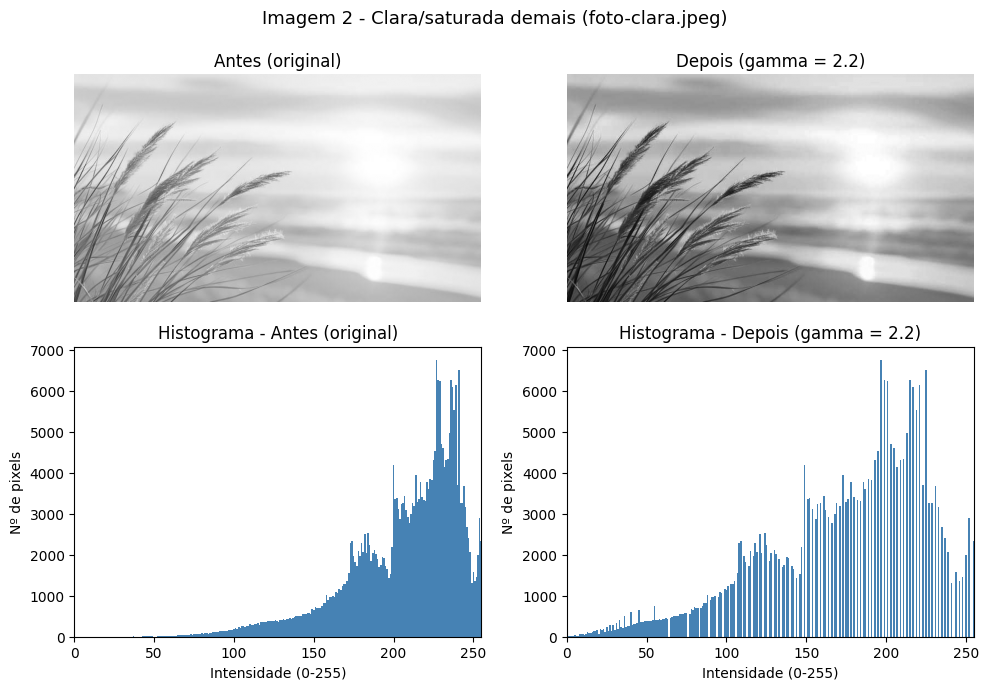

In [9]:
gamma2 = 2.2
out2 = corrigir_gamma(gray2, gamma=gamma2)

fig2 = figura_antes_depois(
    gray2, out2,
    "Antes (original)", f"Depois (gamma = {gamma2})",
    f"Imagem 2 - Clara/saturada demais ({nome2})"
)


## 4. Imagem 3 — Foto bem exposta

Cena noturna de rua, com carro em primeiro plano, faróis, semáforos e janelas iluminadas ao fundo.


Envie a foto BEM EXPOSTA:


Saving foto-exposta.jpeg to foto-exposta.jpeg
Carregado: foto-exposta.jpeg  |  shape: (452, 678, 3)


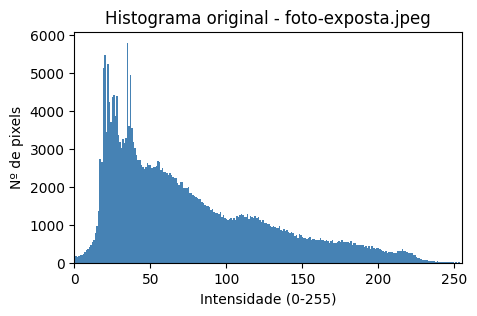

Média: 76.2  |  Desvio padrão: 52.0
Sombras (0-63): 51.7%  |  Meios-tons (64-191): 44.5%  |  Realces (192-255): 3.8%


In [10]:
img3_bgr, nome3 = carregar_upload("Envie a foto BEM EXPOSTA:")
gray3 = cv2.cvtColor(img3_bgr, cv2.COLOR_BGR2GRAY)

histograma(gray3, f"Histograma original - {nome3}")
plt.show()
resumo_histograma(gray3)


### Diagnóstico

O histograma tem pico nos tons escuros, entre 30 e 50, mas decai de forma contínua e mantém massa em toda a extensão da faixa: 51.7% em sombras, 44.5% em meios-tons e 3.8% em realces, com média 76.2 e desvio padrão 52.0 — quase cinco vezes a dispersão da imagem subexposta. O predomínio das sombras vem da cena, que é noturna, e não de um erro de exposição: há informação em todos os níveis, da lataria escura do carro aos faróis e às janelas acesas, e não existe pico colado em 0 nem em 255, ou seja, não houve corte de detalhe nas sombras nem estouro nos realces.

### Operação escolhida: equalização de histograma

Esta imagem não pede correção de direção — não está escura nem clara demais —, então não faz sentido aplicar um gamma para clarear ou escurecer, nem uma expansão de contraste num histograma que já ocupa a faixa inteira. A equalização é a operação adequada para o caso: ela não decide clarear ou escurecer, apenas redistribui as intensidades segundo a função de distribuição acumulada da própria imagem. Por ser definida pela CDF, não tem parâmetro livre a ajustar.

O resultado mostra o comportamento típico da equalização: como a maior parte dos pixels está na região de sombras, a CDF sobe abruptamente ali e esses tons são esticados sobre um intervalo largo de saída. As fachadas e o asfalto clareiam, o histograma final fica com o aspecto serrilhado característico (níveis vazios entre picos, efeito da natureza discreta da transformação em 8 bits) e a atmosfera noturna da cena se perde em parte, ainda que a imagem original já estivesse correta.


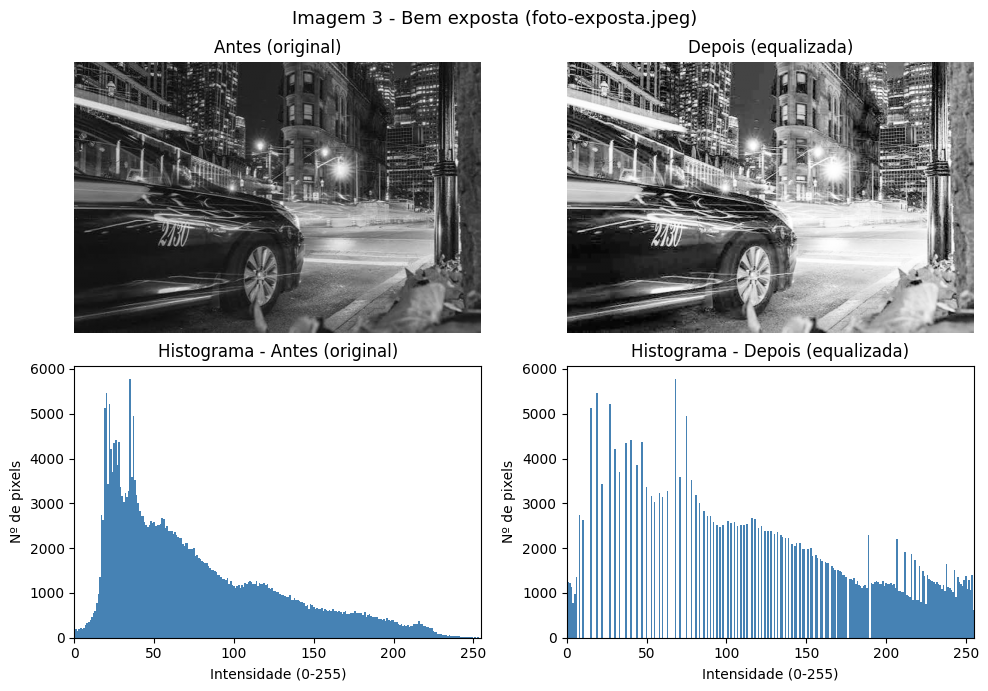

In [11]:
out3 = equalizar(gray3)

fig3 = figura_antes_depois(
    gray3, out3,
    "Antes (original)", "Depois (equalizada)",
    f"Imagem 3 - Bem exposta ({nome3})"
)


## 5. Comparação final

A célula abaixo mede a diferença média absoluta entre cada imagem e seu resultado, quantificando o quanto cada operação efetivamente alterou os pixels.


In [12]:
diff1 = np.mean(np.abs(gray1.astype(np.float32) - out1.astype(np.float32)))
diff2 = np.mean(np.abs(gray2.astype(np.float32) - out2.astype(np.float32)))
diff3 = np.mean(np.abs(gray3.astype(np.float32) - out3.astype(np.float32)))

print("Diferença média absoluta (antes vs depois):")
print(f"  Imagem 1 (escura):         {diff1:.2f}")
print(f"  Imagem 2 (clara/saturada): {diff2:.2f}")
print(f"  Imagem 3 (bem exposta):    {diff3:.2f}")


Diferença média absoluta (antes vs depois):
  Imagem 1 (escura):         78.92
  Imagem 2 (clara/saturada): 40.23
  Imagem 3 (bem exposta):    53.18


### Em qual das três imagens a operação fez menos diferença? Por quê?

A operação fez menos diferença na imagem clara/saturada: a diferença média absoluta entre antes e depois foi de 40.23, contra 53.18 na bem exposta e 78.92 na escura. A razão está na combinação entre o formato do histograma e o da curva aplicada. A transformação de potência tem ponto fixo nos extremos da faixa — para qualquer γ, 0 continua 0 e 255 continua 255 —, de modo que quanto mais perto do topo está um pixel, menos ele se desloca: com γ = 2.2, um pixel em 250 cai apenas para 244 e um em 230 cai para 203, enquanto um em 192 cai para 136. Como 72.2% dos pixels dessa imagem estão acima de 191, a maior parte dela cai na região em que a curva mais se aproxima da identidade, e o deslocamento médio acaba modesto. Na imagem escura acontece o oposto: 98.4% dos pixels estão comprimidos num pico em torno de 30, justamente onde a curva com γ < 1 é mais íngreme, e praticamente toda a imagem é remapeada de uma vez para perto de 108 — tanto que a diferença média medida, 78.92, quase coincide com o deslocamento do próprio pico. A imagem bem exposta fica entre as duas, mas ainda assim muda bastante, porque a equalização não depende da posição do pixel na faixa e sim da distribuição acumulada: com mais da metade dos pixels concentrada nas sombras, a CDF sobe abruptamente ali e esses tons são espalhados por um intervalo largo de saída. Vale notar o que a comparação revela: a magnitude da mudança não mede o quanto a imagem precisava ser corrigida — a foto já bem exposta foi alterada mais do que a superexposta —, o que mostra que a operação e seu parâmetro devem ser escolhidos a partir da forma do histograma, e não aplicados de maneira automática.